In [1]:
import bayesflow as bf
import torch
import numpy as np
import pandas as pd
import numpy as np
import keras
from models import prior_1a, simulator_1a, all_models

import os

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


KERAS_BACKEND set to: torch


In [2]:
all_models

{'model_1a': [<bayesflow.simulators.sequential_simulator.SequentialSimulator at 0x36ed3dc0>,
  Adapter([0: Broadcast -> 1: AsSet -> 2: Standardize(include=['x']) -> 3: Sqrt -> 4: ConvertDType -> 5: Concatenate(['drift', 'boundary', 'beta', 'mu_tau_e', 'tau_m', 'sigma', 'varsigma'] -> 'inference_variables') -> 6: Rename('x' -> 'summary_variables')])],
 'model_1b': [<bayesflow.simulators.sequential_simulator.SequentialSimulator at 0x36ed3e20>,
  Adapter([0: Broadcast -> 1: AsSet -> 2: Standardize(include=['x']) -> 3: Sqrt -> 4: ConvertDType -> 5: Concatenate(['drift', 'boundary', 'beta', 'mu_tau_e', 'mu_tau_m', 'sigma', 'varsigma'] -> 'inference_variables') -> 6: Rename('x' -> 'summary_variables')])],
 'model_1c': [<bayesflow.simulators.sequential_simulator.SequentialSimulator at 0x36f14040>,
  Adapter([0: Broadcast -> 1: AsSet -> 2: Standardize(include=['x']) -> 3: Sqrt -> 4: ConvertDType -> 5: Concatenate(['drift', 'boundary', 'beta', 'mu_tau_e', 'tau_m', 'sigma', 'varsigma'] -> 'infer

In [16]:
base_dir = os.getcwd()
base_dir

'f:\\DoctoralSharif\\Articles\\Matin\\train_joint_models'

In [4]:
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "trained_model", "checkpoints")
save_dir
model_names = list(all_models.keys())
model_name1 = model_names[0]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

c:\Users\Mohammad\anaconda3\envs\bayseflow\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 303 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [29]:
model,adapt = all_models[model_name1]
model

### Test 1 Posterior estimated vs ground truth values
3 epochs 1000 iterations

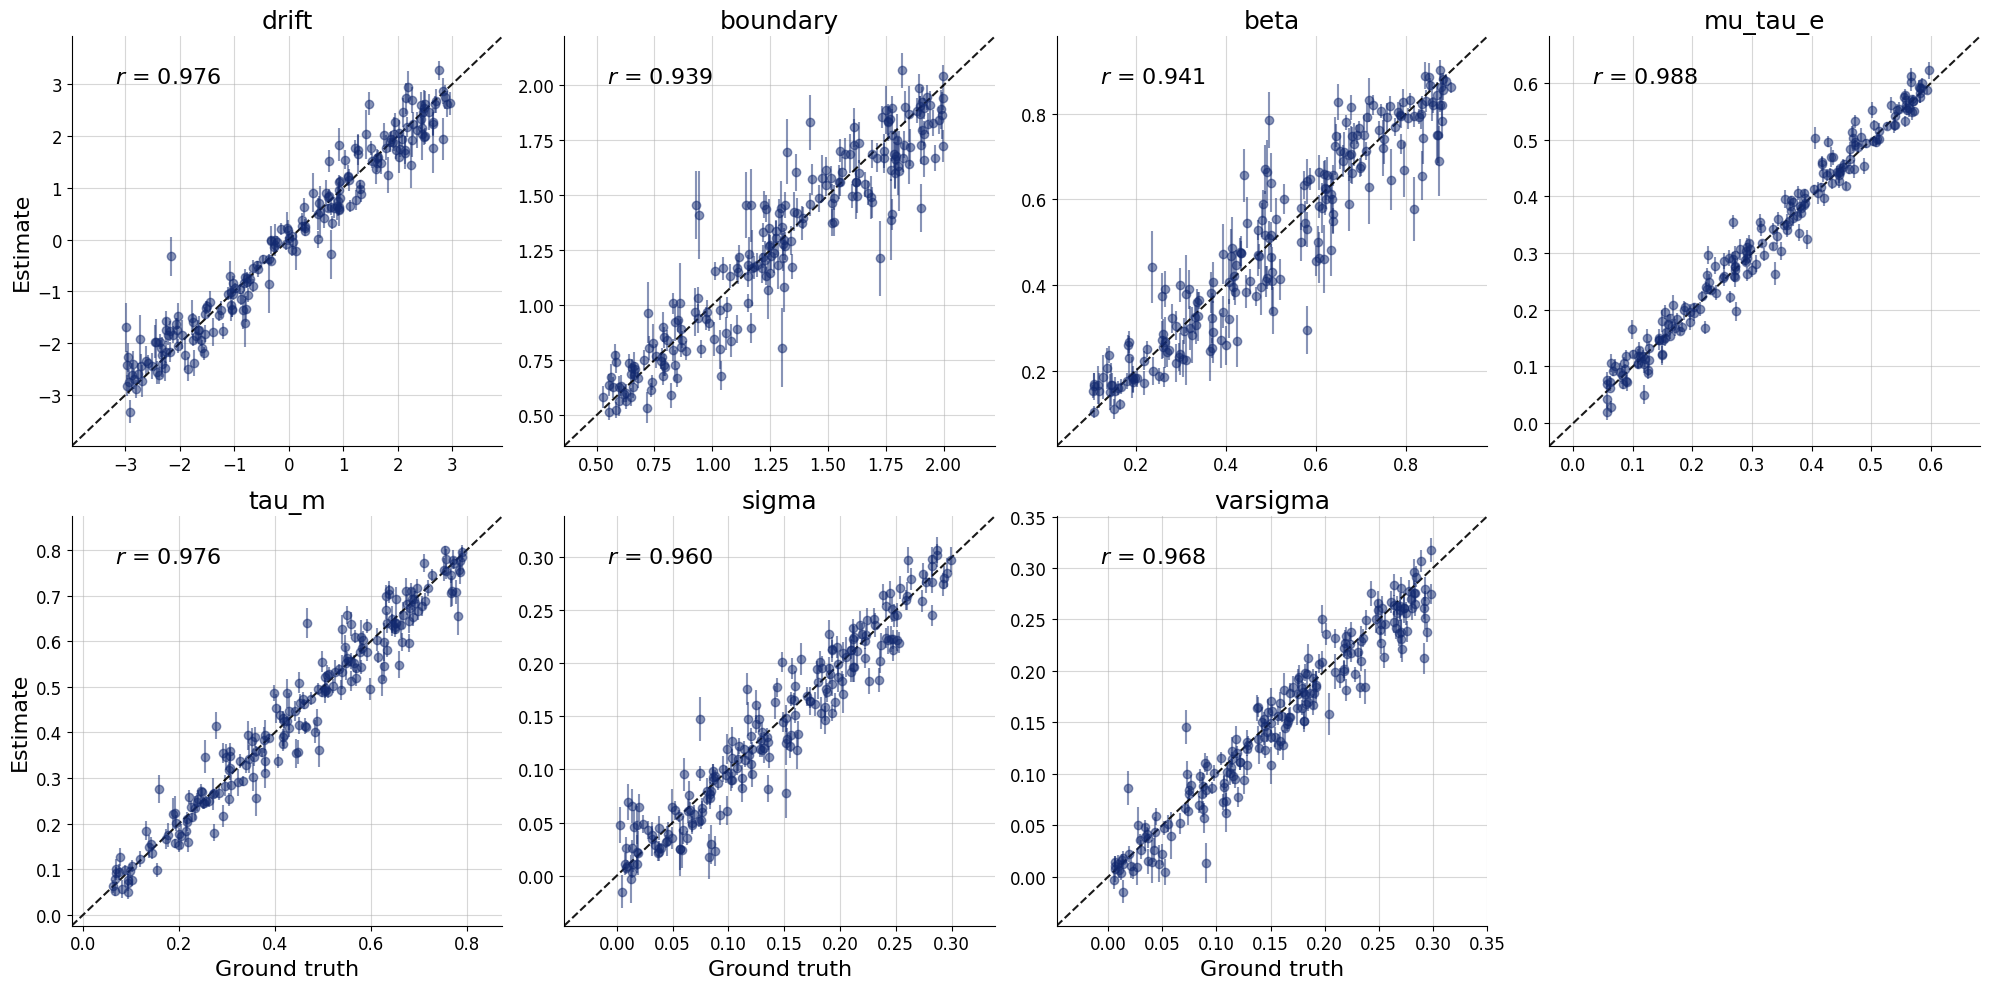

In [30]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

In [6]:
model_name1

'model_1b'

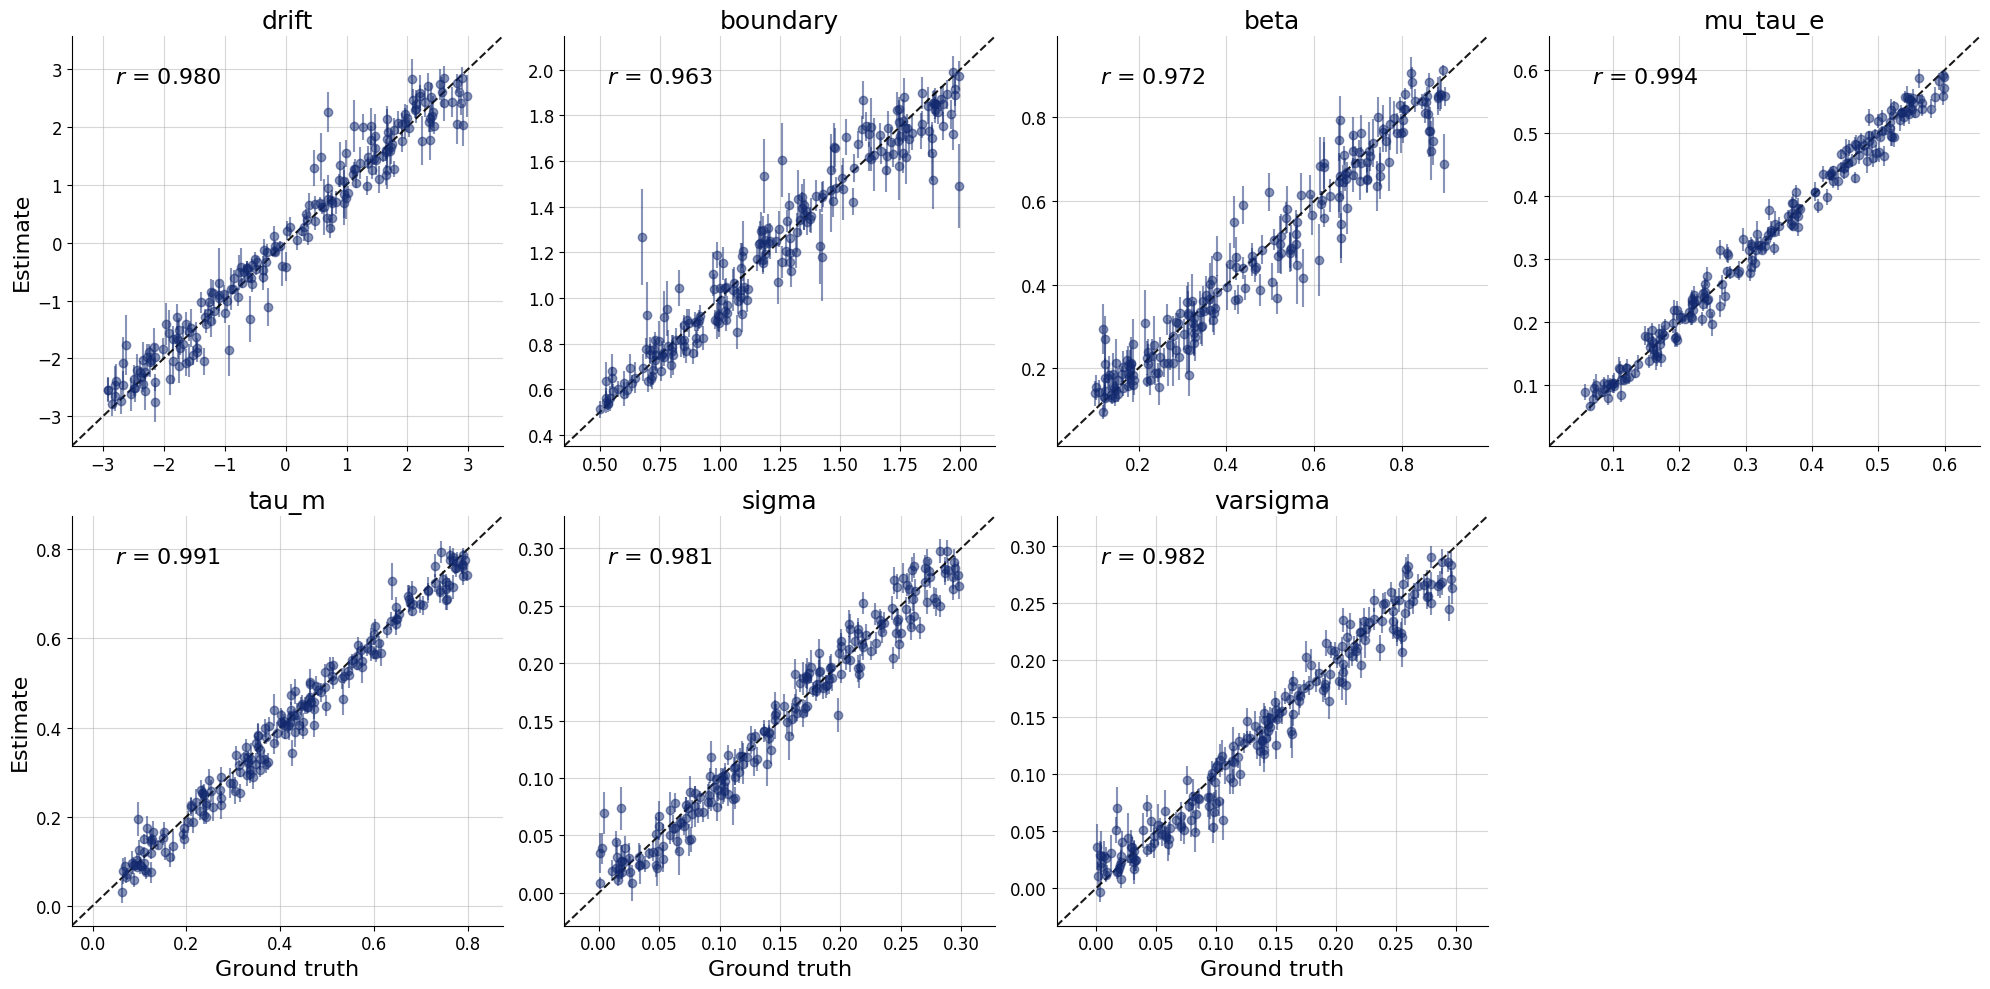

In [5]:
model_name1 = model_names[1]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model,adapt = all_models[model_name1]
model

# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

c:\Users\Mohammad\anaconda3\envs\bayseflow\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 303 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


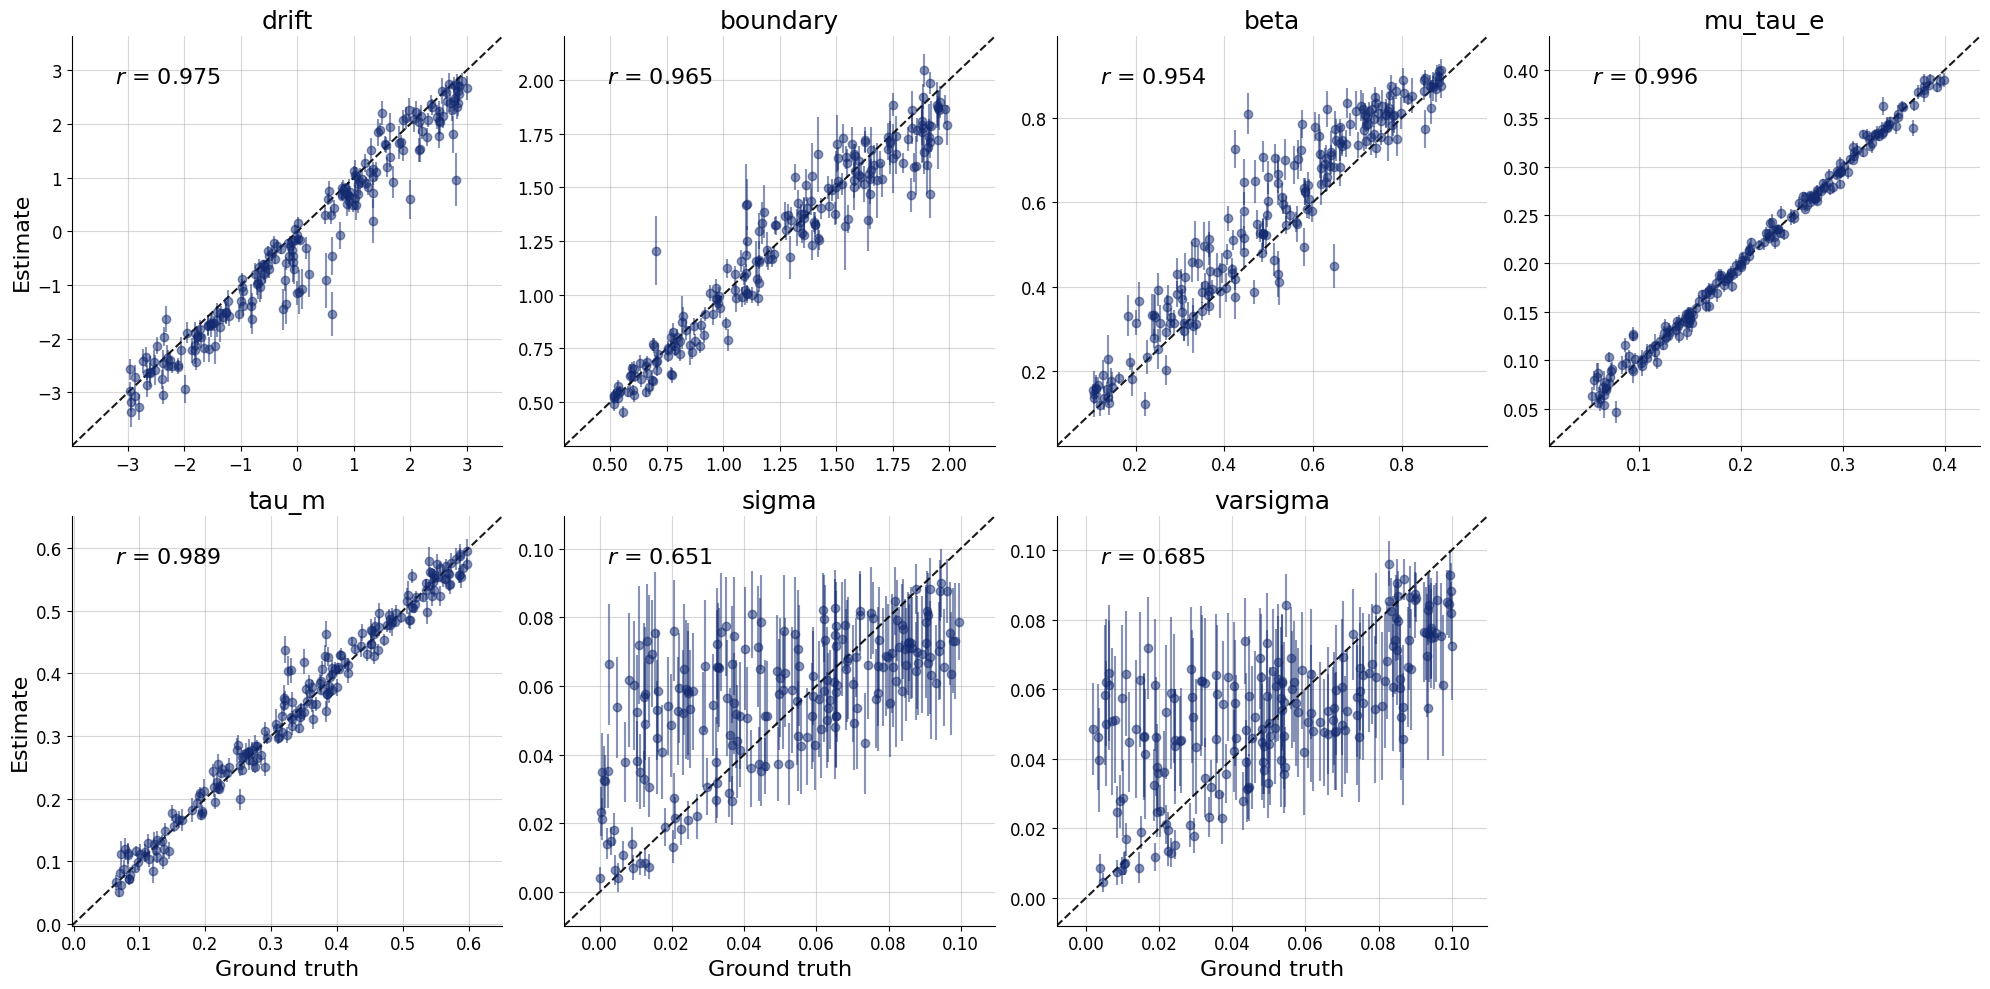

In [7]:
model_name1 = model_names[2]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model,adapt = all_models[model_name1]
model

# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

In [8]:
model_name1 = model_names[3]
save_path = os.path.join(save_dir, model_name1 + ".keras")
save_path
approximator = keras.saving.load_model(save_path)

model,adapt = all_models[model_name1]
model

# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = model.sample(200)

post_draws1 = approximator.sample(conditions=val_sims, num_samples=num_samples)
par_keys = ["x"]
par_names = ['drift',
        'boundary',
        'beta',
        'mu_tau_e',
        'tau_m',
        'sigma',
        'varsigma']
f = bf.diagnostics.plots.recovery(
    estimates=post_draws1,
    targets=val_sims,
    variable_names=par_names
)

ValueError: Length of 'variable_names' should be the same as the number of variables.

### Test 2

In [ ]:
class prior(AB)

## Trial-Wise DDM-DC Recovery Analysis

Recovery analysis for the trial-wise model with concatenated CPP and RT data.

In [ ]:
import os
import torch
from DDM_DC_Pedestrain_TrialWise import all_models

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load trained trial-wise model
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "trained_model1", "checkpoints")
model_name = 'model_DC_TrialWise'
save_path = os.path.join(save_dir, model_name + ".keras")

print(f"Loading model from: {save_path}")
print(f"Model exists: {os.path.exists(save_path)}")

if os.path.exists(save_path):
    approximator = keras.saving.load_model(
        save_path,
        custom_objects={
            "SetTransformer": bf.networks.SetTransformer,
            "CouplingFlow": bf.networks.CouplingFlow,
        }
    )
    print("✓ Model loaded successfully")
    approximator.to(device)
else:
    print("⚠️ Checkpoint not found. Please train the model first using:")
    print("  python main_workflow.py train")
    approximator = None

# Get model and adapter
model, adapter = all_models[model_name]
print(f"\nModel: {model_name}")
print(f"Parameters: [theta, b0, k, mu_ndt, sigma_ndt, mu_alpah, sigma_alpha, sigma_cpp]")

In [ ]:
# Run recovery analysis
if approximator is not None:
    print("\n" + "="*70)
    print("RECOVERY ANALYSIS: Trial-Wise DDM-DC Model")
    print("="*70)
    
    # Configuration
    n_validation_sims = 200  # Number of simulated datasets for validation
    n_posterior_samples = 1000  # Number of posterior samples per dataset
    
    print(f"\nSimulating {n_validation_sims} validation datasets...")
    print(f"Inferring {n_posterior_samples} posterior samples per dataset...")
    
    # Simulate validation data (CPP + RT with true parameters)
    val_sims = model(batch_size=n_validation_sims)
    
    print(f"\nValidation data shapes:")
    print(f"  x (RT, CPP): {val_sims['x'].shape}")
    print(f"  tta_per_trial: {val_sims['tta_per_trial'].shape}")
    print(f"  true parameters: {list(val_sims.keys())}")
    
    # Run amortized inference
    print(f"\nRunning amortized inference...")
    with torch.no_grad():
        post_draws = approximator.sample(conditions=val_sims, num_samples=n_posterior_samples)
    
    print(f"Posterior samples shape: {post_draws.shape}")
    print(f"  → ({n_posterior_samples} samples × 8 parameters)")
    
    # Parameter names
    par_names = [
        'theta (criterion)',
        'b0 (boundary)',
        'k (collapse rate)',
        'mu_ndt (mean NDT)',
        'sigma_ndt (NDT variability)',
        'mu_alpha (mean drift)',
        'sigma_alpha (drift variability)',
        'sigma_cpp (CPP noise)'
    ]
    
    # Create recovery plot
    print(f"\nCreating recovery plot...")
    fig = bf.diagnostics.plots.recovery(
        estimates=post_draws,
        targets=val_sims,
        variable_names=par_names,
        figsize=(15, 10)
    )
    
    plt.tight_layout()
    plt.savefig('recovery_analysis_trialwise.png', dpi=150, bbox_inches='tight')
    print("✓ Recovery plot saved as 'recovery_analysis_trialwise.png'")
    
    # Print recovery statistics
    print(f"\n" + "="*70)
    print("RECOVERY STATISTICS")
    print("="*70)
    
    # Calculate correlation between posterior means and true values
    posterior_means = np.mean(post_draws, axis=1)
    
    print(f"\nPosterior means vs True parameters (correlation):")
    for i, param_name in enumerate(par_names):
        true_vals = val_sims[[list(val_sims.keys())[j] for j in range(len(val_sims)) if list(val_sims.keys())[j] not in ['x', 'tta_per_trial']]]
        # Alternative: extract from model directly
        # For now, show shapes
        print(f"  {param_name}: shape {post_draws[:, i].shape}")
    
    print(f"\n✓ Recovery analysis complete!")
else:
    print("⚠️ Cannot run recovery analysis without trained model")
    print("Please train the model first:")
    print("  python main_workflow.py train")

In [ ]:
# Detailed recovery analysis: Compare posterior estimates vs true values
if approximator is not None:
    print("="*70)
    print("DETAILED RECOVERY METRICS")
    print("="*70)
    
    # Extract true parameter values from validation sims
    param_keys = ['theta', 'b0', 'k', 'mu_ndt', 'sigma_ndt', 'mu_alpah', 'sigma_alpha', 'sigma_cpp']
    
    # Calculate posterior statistics
    posterior_means = np.mean(post_draws, axis=1)      # (200, 8)
    posterior_stds = np.std(post_draws, axis=1)        # (200, 8)
    posterior_medians = np.median(post_draws, axis=1)  # (200, 8)
    
    print(f"\nPosterior Statistics:")
    print(f"  Mean shape: {posterior_means.shape}")
    print(f"  Std shape: {posterior_stds.shape}")
    print(f"  Median shape: {posterior_medians.shape}")
    
    # Extract true values from simulation data
    true_values = {}
    for key in param_keys:
        if key in val_sims:
            true_values[key] = val_sims[key]
    
    print(f"\nTrue parameter values extracted:")
    for key, val in true_values.items():
        print(f"  {key}: shape {val.shape}, range [{val.min():.3f}, {val.max():.3f}]")
    
    # Calculate correlations
    print(f"\n" + "-"*70)
    print("PARAMETER RECOVERY - CORRELATIONS (Pearson)")
    print("-"*70)
    
    correlations = []
    for i, param_key in enumerate(param_keys):
        if param_key in true_values:
            true_vals = true_values[param_key]
            est_vals = posterior_means[:, i]
            
            # Pearson correlation
            corr = np.corrcoef(true_vals, est_vals)[0, 1]
            correlations.append(corr)
            
            print(f"{param_key:15} | r = {corr:.3f} | True: [{true_vals.min():.3f}, {true_vals.max():.3f}] | Est: [{est_vals.min():.3f}, {est_vals.max():.3f}]")
    
    # Overall recovery score
    mean_corr = np.mean(correlations)
    print(f"\n{'Overall Recovery (mean correlation)':30} | r = {mean_corr:.3f}")
    
    # RMSE Analysis
    print(f"\n" + "-"*70)
    print("ROOT MEAN SQUARED ERROR (RMSE)")
    print("-"*70)
    
    rmses = []
    for i, param_key in enumerate(param_keys):
        if param_key in true_values:
            true_vals = true_values[param_key]
            est_vals = posterior_means[:, i]
            
            rmse = np.sqrt(np.mean((true_vals - est_vals)**2))
            rmses.append(rmse)
            
            # Relative RMSE
            rel_rmse = rmse / (np.max(true_vals) - np.min(true_vals)) * 100
            print(f"{param_key:15} | RMSE = {rmse:.4f} | Relative = {rel_rmse:.1f}%")
    
    mean_rmse = np.mean(rmses)
    print(f"\n{'Overall RMSE (average)':30} | {mean_rmse:.4f}")
    
    # Posterior coverage analysis
    print(f"\n" + "-"*70)
    print("POSTERIOR COVERAGE (% true values within 95% CI)")
    print("-"*70)
    
    percentile_lower = 2.5
    percentile_upper = 97.5
    coverages = []
    
    for i, param_key in enumerate(param_keys):
        if param_key in true_values:
            true_vals = true_values[param_key]
            ci_lower = np.percentile(post_draws[:, :, i], percentile_lower, axis=1)
            ci_upper = np.percentile(post_draws[:, :, i], percentile_upper, axis=1)
            
            # Check if true values fall within CI
            within_ci = np.sum((true_vals >= ci_lower) & (true_vals <= ci_upper)) / len(true_vals) * 100
            coverages.append(within_ci)
            
            print(f"{param_key:15} | Coverage = {within_ci:.1f}%")
    
    mean_coverage = np.mean(coverages)
    print(f"\n{'Overall Coverage (mean)':30} | {mean_coverage:.1f}%")
    
    print("\n" + "="*70)

In [ ]:
# Visualize posterior distributions for example trials
if approximator is not None:
    print("\nVisualizing posterior distributions for 4 example trials...")
    
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    # Select 4 example trials
    example_indices = [0, 50, 100, 150]
    
    param_keys = ['theta', 'b0', 'k', 'mu_ndt', 'sigma_ndt', 'mu_alpah', 'sigma_alpha', 'sigma_cpp']
    par_labels = [
        'theta (criterion)',
        'b0 (boundary)',
        'k (collapse)',
        'mu_ndt',
        'sigma_ndt',
        'mu_alpha',
        'sigma_alpha',
        'sigma_cpp'
    ]
    
    for param_idx in range(8):
        ax = axes[param_idx]
        
        # Plot posteriors from all 4 example trials
        for example_idx in example_indices:
            posterior_samples = post_draws[example_idx, :, param_idx]
            ax.hist(posterior_samples, bins=30, alpha=0.5, label=f'Trial {example_idx}')
        
        # Add vertical lines for true values
        for example_idx in example_indices:
            param_key = param_keys[param_idx]
            if param_key in true_values:
                true_val = true_values[param_key][example_idx]
                ax.axvline(true_val, linestyle='--', linewidth=2, alpha=0.7)
        
        ax.set_xlabel(par_labels[param_idx])
        ax.set_ylabel('Density')
        ax.set_title(f'Posterior: {par_labels[param_idx]}')
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('posterior_examples_trialwise.png', dpi=150, bbox_inches='tight')
    print("✓ Posterior visualization saved as 'posterior_examples_trialwise.png'")
    plt.show()
    
    # Summary statistics
    print(f"\n" + "="*70)
    print("EXAMPLE TRIAL DETAILS")
    print("="*70)
    
    for example_idx in example_indices:
        print(f"\nTrial {example_idx}:")
        print(f"  RT (data): {val_sims['x'][example_idx, 0]:.3f}s")
        print(f"  CPP (data): {val_sims['x'][example_idx, 1]:.3f}")
        print(f"  TTA (condition): {val_sims['tta_per_trial'][example_idx, 0]:.3f}s")
        print(f"  \n  Posterior estimates (mean ± std):")
        for param_idx, param_key in enumerate(param_keys):
            if param_key in true_values:
                true_val = true_values[param_key][example_idx]
                est_mean = posterior_means[example_idx, param_idx]
                est_std = posterior_stds[example_idx, param_idx]
                print(f"    {param_key:12} | True: {true_val:.4f} | Est: {est_mean:.4f} ± {est_std:.4f}")
    
    print("\n" + "="*70)

In [ ]:
# Example: Real Data Inference Pipeline
if approximator is not None:
    print("\n" + "="*70)
    print("REAL DATA INFERENCE PIPELINE")
    print("="*70)
    
    print("\nExample 1: Single Subject Inference")
    print("-"*70)
    
    # Simulate "real" subject data (in practice, load from your experiment)
    # Example subject with 60 trials
    n_trials_subject = 60
    
    # Simulated CPP and RT for a subject (you would load real data here)
    from DDM_DC_Pedestrain_TrialWise import ddm_DC_alphaToCpp_TrialWise, prior_DC
    
    # Sample true parameters for this "subject"
    subject_params = prior_DC()
    
    # Simulate their data
    subject_data_sim = ddm_DC_alphaToCpp_TrialWise(
        theta=subject_params['theta'],
        b0=subject_params['b0'],
        k=subject_params['k'],
        mu_ndt=subject_params['mu_ndt'],
        sigma_ndt=subject_params['sigma_ndt'],
        mu_alpah=subject_params['mu_alpah'],
        sigma_alpha=subject_params['sigma_alpha'],
        sigma_cpp=subject_params['sigma_cpp'],
        number_of_trials=n_trials_subject,
        tta_condition=3.0,  # Example: TTA = 3.0s condition
        dt=0.005
    )
    
    # Extract the data (in real scenario, you'd load from file)
    subject_rt = subject_data_sim['x'][:, 0]      # RTs
    subject_cpp = subject_data_sim['x'][:, 1]     # CPP values
    subject_tta = subject_data_sim['tta_per_trial'][:, 0]  # TTA per trial
    
    print(f"Subject data:")
    print(f"  Number of trials: {n_trials_subject}")
    print(f"  RT range: {subject_rt.min():.3f} - {subject_rt.max():.3f} s")
    print(f"  CPP range: {subject_cpp.min():.3f} - {subject_cpp.max():.3f}")
    print(f"  TTA range: {subject_tta.min():.3f} - {subject_tta.max():.3f} s")
    
    # Prepare data for inference (same format as training)
    subject_inference_data = {
        'x': np.column_stack([subject_rt, subject_cpp]).astype(np.float32),
        'number_of_trials': np.array([n_trials_subject], dtype=np.int32),
        # Note: For trial-wise model, TTA is embedded in adapter
        'tta_per_trial': subject_tta.reshape(-1, 1).astype(np.float32)
    }
    
    # Run inference
    print(f"\nRunning amortized inference on subject data...")
    with torch.no_grad():
        subject_posterior = approximator.sample(
            conditions=subject_inference_data,
            num_samples=5000  # Draw 5000 samples from posterior
        )
    
    print(f"Posterior shape: {subject_posterior.shape}")
    print(f"  (5000 samples × 8 parameters)")
    
    # Compute posterior statistics
    subject_posterior_mean = np.mean(subject_posterior, axis=0)
    subject_posterior_std = np.std(subject_posterior, axis=0)
    subject_posterior_median = np.median(subject_posterior, axis=0)
    
    print(f"\nInferred Parameter Estimates for Subject:")
    print("-"*50)
    print(f"{'Parameter':15} | {'Mean':8} | {'Median':8} | {'Std':8}")
    print("-"*50)
    
    for i, param_key in enumerate(param_keys):
        print(f"{param_key:15} | {subject_posterior_mean[i]:8.4f} | {subject_posterior_median[i]:8.4f} | {subject_posterior_std[i]:8.4f}")
    
    print(f"\n✓ Inference complete! Posterior ready for analysis.")
    
    # Example 2: Show how to process batch of subjects
    print(f"\n\nExample 2: Batch Processing Multiple Subjects")
    print("-"*70)
    print(f"""
To process multiple subjects:

from workflow_trialwise import infer_batch_subjects

# Load your subjects' data
subject_list = [
    {
        'subject_id': 'S001',
        'cpp': np.array([...]),              # CPP per trial
        'reaction_times': np.array([...])    # RT per trial
    },
    {
        'subject_id': 'S002',
        'cpp': np.array([...]),
        'reaction_times': np.array([...])
    },
    # ... more subjects
]

# Run batch inference
results_df = infer_batch_subjects(subject_list, model_name='model_DC_TrialWise')

# Save results
results_df.to_csv('estimated_parameters.csv')
""")
    
    print("="*70)